# UAS Pengolahan Bahasa Alami — ABSA: Multilabel Text Classification & NER
**Mata Kuliah:** Pengolahan Bahasa Alami  
**Prodi:** Informatika — Universitas Atma Jaya Yogyakarta  
**Tahun Akademik:** 2025/2026

Notebook ini mengerjakan dua proyek secara terpadu:
- **Proyek A**: Multilabel Text Classification ABSA
- **Proyek B**: Named Entity Recognition (NER) ABSA

Dataset berasal dari hasil anotasi proyek UTS menggunakan tool Prodigy, format JSONL.  
Annotator yang digunakan: `nlp5_genap2526-230712326`.


---
## 0. Setup & Instalasi Dependensi

Install semua library yang dibutuhkan untuk kedua proyek.


In [ ]:
%pip install --quiet scikit-learn scikit-multilearn gensim seqeval transformers torch torchcrf
%pip install --quiet matplotlib seaborn pandas numpy tqdm

In [ ]:
!pip install pytorch-crf

In [ ]:
import json, re, os, random, pickle, warnings
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (classification_report, hamming_loss,
                              accuracy_score, f1_score, confusion_matrix)

from sklearn.multioutput import ClassifierChain
from sklearn.multiclass import OneVsRestClassifier
from sklearn.base import clone

from gensim.models import FastText

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModel,
                          get_linear_schedule_with_warmup)

from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('Setup selesai ✓')


Device: cuda
Setup selesai ✓



A — Multilabel Text Classification ABSA


## A.1 Data Loading dan Validasi Dataset

Dataset anotasi dalam format JSONL dibaca dari file `Kelp5_dataset_anotasi.jsonl`.  
Hanya anotasi dari annotator `230712326` dengan status `accept` yang digunakan.

Struktur tiap record:
- `text`: teks review asli
- `tokens`: list token dengan offset karakter
- `spans`: list span entitas dengan `token_start`, `token_end`, `label`
- `accept`: list label multilabel yang diberikan annotator
- `_annotator_id`: ID annotator


In [ ]:
JSONL_PATH = '/content/Kelp5_dataset_anotasi.jsonl'

raw_records = []
with open(JSONL_PATH, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            raw_records.append(json.loads(line))

print(f'Total records (semua annotator): {len(raw_records)}')
print(f'Annotator unik: {set(r.get("_annotator_id","") for r in raw_records)}')


Total records (semua annotator): 1607
Annotator unik: {'nlp5_genap2526-230712368', 'nlp5_genap2526-230712326'}


In [ ]:
TARGET_ANN = 'nlp5_genap2526-230712326'

ann_records = [
    r for r in raw_records
    if r.get('_annotator_id') == TARGET_ANN and r.get('answer') == 'accept'
]
print(f'Records dari {TARGET_ANN} (accepted): {len(ann_records)}')

ALL_LABELS = [
    'PRODUCT_POSITIVE','PRODUCT_NEGATIVE','PRODUCT_NEUTRAL',
    'PRICE_POSITIVE','PRICE_NEGATIVE','PRICE_NEUTRAL',
    'PLACE_POSITIVE','PLACE_NEGATIVE','PLACE_NEUTRAL',
    'PROMOTION_POSITIVE','PROMOTION_NEGATIVE','PROMOTION_NEUTRAL',
    'OUT_OF_TOPIC'
]

rows = []
for r in ann_records:
    accept = r.get('accept') or []
    row = {'text': r['text'], 'labels': accept}
    for lbl in ALL_LABELS:
        row[lbl] = 1 if lbl in accept else 0
    rows.append(row)

df_multi = pd.DataFrame(rows)
print(f'Shape: {df_multi.shape}')
display(df_multi[['text','labels'] + ALL_LABELS].head(3))


Records dari nlp5_genap2526-230712326 (accepted): 1013
Shape: (1013, 15)


,text,labels,PRODUCT_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRICE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PLACE_POSITIVE,PLACE_NEGATIVE,PLACE_NEUTRAL,PROMOTION_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,OUT_OF_TOPIC
0,Bisa self checkout jadi gak usah antri mau bay...,[PLACE_POSITIVE],0,0,0,0,0,0,1,0,0,0,0,0,0
1,Tempat yang cocok untuk cari yang casual dan s...,[PLACE_POSITIVE],0,0,0,0,0,0,1,0,0,0,0,0,0
2,"Guys, ada yg hbs self payment disini terus kar...",[OUT_OF_TOPIC],0,0,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
print('=== Validasi Dataset ===')
print(f'Kolom teks tersedia  : {"text" in df_multi.columns}')
print(f'Kolom label tersedia : {all(l in df_multi.columns for l in ALL_LABELS)}')
print(f'Nilai null di teks   : {df_multi["text"].isnull().sum()}')
print(f'Teks kosong          : {(df_multi["text"].str.strip() == "").sum()}')
print(f'Record tanpa label   : {(df_multi[ALL_LABELS].sum(axis=1) == 0).sum()}')
print()
print('Distribusi label:')
label_counts = df_multi[ALL_LABELS].sum().sort_values(ascending=False)
display(label_counts.to_frame('jumlah'))


=== Validasi Dataset ===
Kolom teks tersedia  : True
Kolom label tersedia : True
Nilai null di teks   : 0
Teks kosong          : 0
Record tanpa label   : 4

Distribusi label:


,jumlah
PRODUCT_POSITIVE,476
OUT_OF_TOPIC,354
PLACE_POSITIVE,289
PROMOTION_POSITIVE,171
PRICE_POSITIVE,100
PRODUCT_NEGATIVE,48
PRICE_NEGATIVE,42
PLACE_NEUTRAL,40
PLACE_NEGATIVE,38
PROMOTION_NEGATIVE,25


## A.2 Data Preprocessing dan Label Engineering

Tahapan:
1. **Text cleaning** — lowercase, hapus karakter non-alfanumerik berlebih, normalisasi spasi
2. **Label encoding** — `MultiLabelBinarizer` untuk representasi biner
3. **Train/validation/test split (70/15/15)** — menggunakan **iterative stratification** (`iterative_train_test_split` dari scikit-multilearn) agar proporsi setiap label ABSA tetap terjaga di ketiga split, mengingat distribusi label yang sangat imbalanced (lihat EDA A.3)
4. **Strategi penanganan label imbalance** — selain split yang stratified, model klasifikasi (LogisticRegression, LinearSVC) dilatih dengan `class_weight='balanced'` agar label minoritas (mis. `PRICE_NEUTRAL`, `PROMOTION_NEUTRAL`) tidak diabaikan model selama training (lihat A.5)

In [ ]:
def clean_text(text: str) -> str:
    """Lowercase, hapus karakter non-huruf/angka/spasi, normalize whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_multi['clean_text'] = df_multi['text'].apply(clean_text)

print('Contoh sebelum vs sesudah cleaning:')
for i in range(3):
    print(f'  BEFORE: {df_multi["text"].iloc[i][:80]}')
    print(f'  AFTER : {df_multi["clean_text"].iloc[i][:80]}')
    print()


Contoh sebelum vs sesudah cleaning:
  BEFORE: Bisa self checkout jadi gak usah antri mau bayar, keren sih packing sendiri baya
  AFTER : bisa self checkout jadi gak usah antri mau bayar keren sih packing sendiri bayar

  BEFORE: Tempat yang cocok untuk cari yang casual dan simple
  AFTER : tempat yang cocok untuk cari yang casual dan simple

  BEFORE: Guys, ada yg hbs self payment disini terus kartu kreditnya dipake transaksi tanp
  AFTER : guys ada yg hbs self payment disini terus kartu kreditnya dipake transaksi tanpa



In [ ]:
mlb = MultiLabelBinarizer(classes=ALL_LABELS)
Y = mlb.fit_transform(df_multi['labels'])
print(f'Label matrix shape: {Y.shape}')
print(f'Label urutan      : {list(mlb.classes_)}')


Label matrix shape: (1013, 13)
Label urutan      : ['PRODUCT_POSITIVE', 'PRODUCT_NEGATIVE', 'PRODUCT_NEUTRAL', 'PRICE_POSITIVE', 'PRICE_NEGATIVE', 'PRICE_NEUTRAL', 'PLACE_POSITIVE', 'PLACE_NEGATIVE', 'PLACE_NEUTRAL', 'PROMOTION_POSITIVE', 'PROMOTION_NEGATIVE', 'PROMOTION_NEUTRAL', 'OUT_OF_TOPIC']


In [ ]:
from skmultilearn.model_selection import iterative_train_test_split

X_text = df_multi['clean_text'].values
idx_all = df_multi.index.values.reshape(-1, 1)  

idx_trainval, Y_trainval, idx_test, Y_test = iterative_train_test_split(
    idx_all, Y, test_size=0.15)

idx_train, Y_train, idx_val, Y_val = iterative_train_test_split(
    idx_trainval, Y_trainval, test_size=0.176)

idx_train = idx_train.flatten()
idx_val   = idx_val.flatten()
idx_test  = idx_test.flatten()

X_train = df_multi.loc[idx_train, 'clean_text'].values
X_val   = df_multi.loc[idx_val,   'clean_text'].values
X_test  = df_multi.loc[idx_test,  'clean_text'].values

print(f'Train : {len(X_train):4d} samples')
print(f'Val   : {len(X_val):4d} samples')
print(f'Test  : {len(X_test):4d} samples')
print(f'Total : {len(X_text):4d} samples')

print('\nProporsi label per split (cek imbalance antar split):')
for name, Yset in [('Train', Y_train), ('Val', Y_val), ('Test', Y_test)]:
    print(f'  {name:5s}:', np.round(Yset.sum(axis=0) / len(Yset), 3))

df_multi.loc[idx_train].to_csv('Kelp1_multilabel_train.csv', index=False)
df_multi.loc[idx_val].to_csv('Kelp1_multilabel_val.csv', index=False)
df_multi.loc[idx_test].to_csv('Kelp1_multilabel_test.csv', index=False)
print('\nDataset split disimpan ke CSV ✓ (iterative stratification)')

Train :  706 samples
Val   :  152 samples
Test  :  155 samples
Total : 1013 samples

Proporsi label per split (cek imbalance antar split):
  Train: [0.473 0.048 0.017 0.096 0.041 0.014 0.288 0.037 0.04  0.169 0.024 0.01
 0.351]
  Val  : [0.467 0.046 0.026 0.112 0.046 0.02  0.283 0.039 0.039 0.171 0.026 0.013
 0.349]
  Test : [0.458 0.045 0.019 0.097 0.039 0.019 0.277 0.039 0.039 0.168 0.026 0.013
 0.342]

Dataset split disimpan ke CSV ✓ (iterative stratification)


## A.3 EDA dan Visualisasi Label


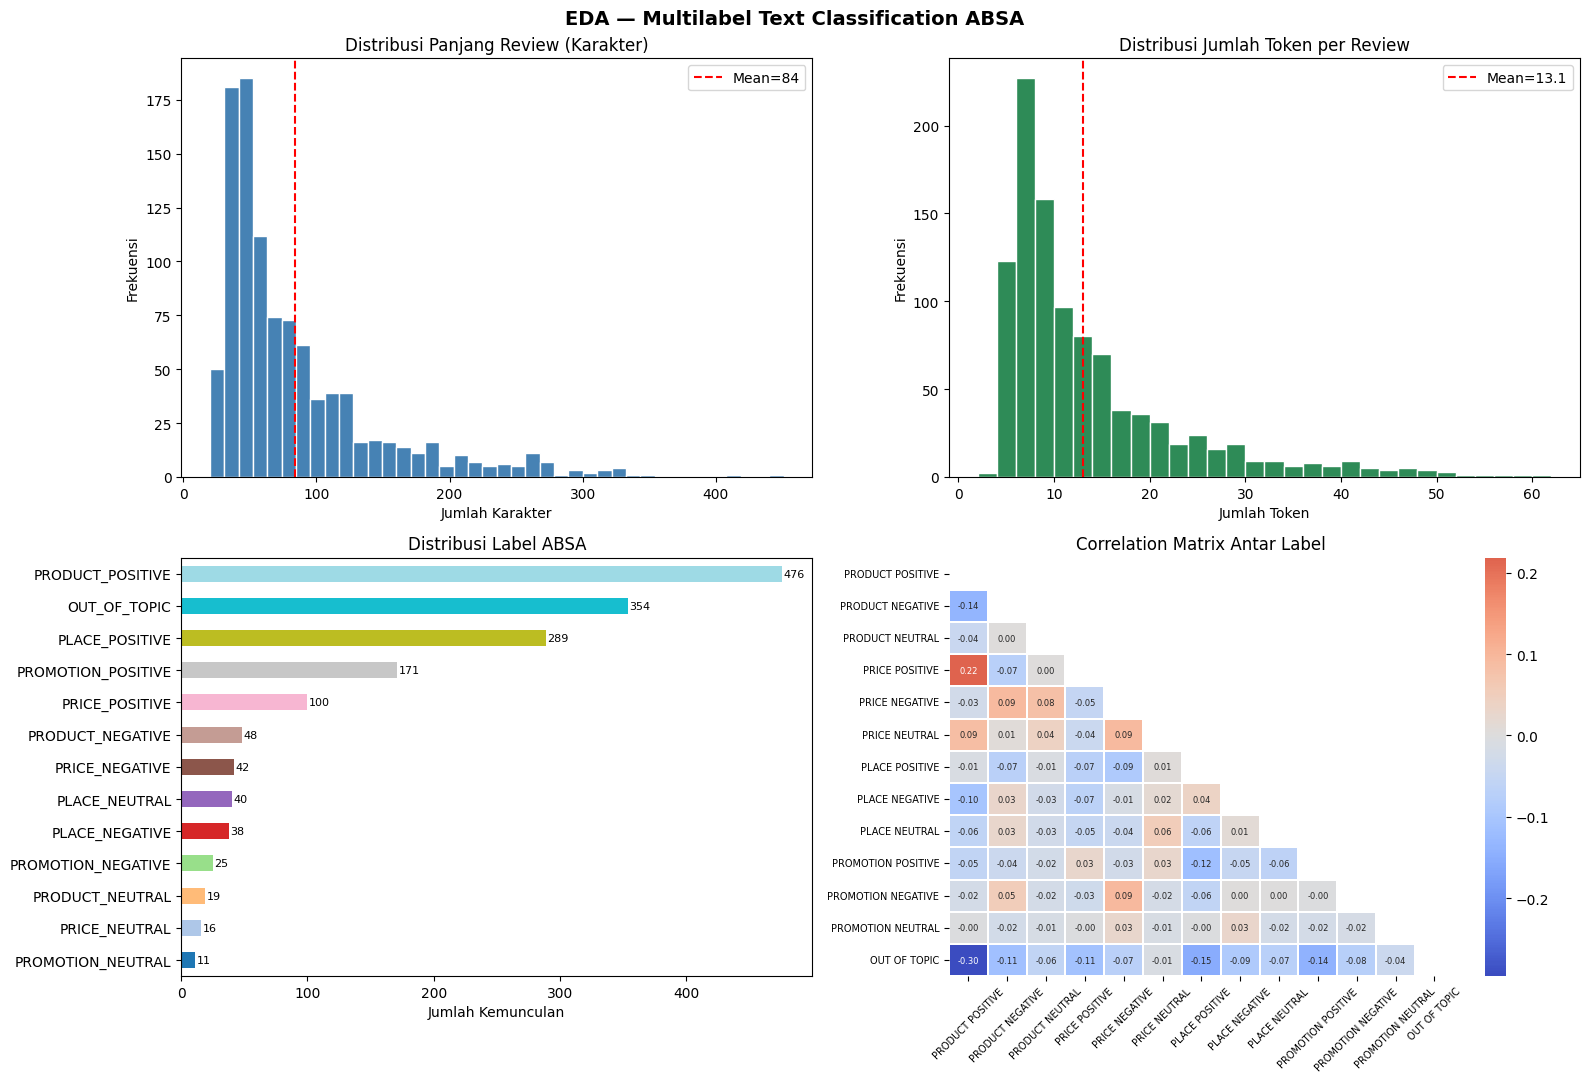

Visualisasi EDA tersimpan.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('EDA — Multilabel Text Classification ABSA', fontsize=14, fontweight='bold')

ax = axes[0, 0]
char_lens = df_multi['text'].str.len()
ax.hist(char_lens, bins=40, color='steelblue', edgecolor='white')
ax.set_title('Distribusi Panjang Review (Karakter)')
ax.set_xlabel('Jumlah Karakter'); ax.set_ylabel('Frekuensi')
ax.axvline(char_lens.mean(), color='red', linestyle='--',
           label=f'Mean={char_lens.mean():.0f}')
ax.legend()

ax = axes[0, 1]
tok_lens = df_multi['clean_text'].str.split().str.len()
ax.hist(tok_lens, bins=30, color='seagreen', edgecolor='white')
ax.set_title('Distribusi Jumlah Token per Review')
ax.set_xlabel('Jumlah Token'); ax.set_ylabel('Frekuensi')
ax.axvline(tok_lens.mean(), color='red', linestyle='--',
           label=f'Mean={tok_lens.mean():.1f}')
ax.legend()

ax = axes[1, 0]
lc = df_multi[ALL_LABELS].sum().sort_values(ascending=True)
colors = plt.cm.tab20(np.linspace(0, 1, len(lc)))
lc.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Distribusi Label ABSA')
ax.set_xlabel('Jumlah Kemunculan')
for i, v in enumerate(lc.values):
    ax.text(v + 1, i, str(int(v)), va='center', fontsize=8)

ax = axes[1, 1]
corr = df_multi[ALL_LABELS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            xticklabels=[l.replace('_',' ') for l in ALL_LABELS],
            yticklabels=[l.replace('_',' ') for l in ALL_LABELS],
            annot_kws={'size': 6})
ax.set_title('Correlation Matrix Antar Label')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig('eda_multilabel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi EDA tersimpan.')


In [ ]:
labels_per_review = df_multi[ALL_LABELS].sum(axis=1)
print('Jumlah label per review:')
print(labels_per_review.value_counts().sort_index().to_string())
print(f'\nRata-rata label per review: {labels_per_review.mean():.2f}')
print(f'Paling banyak             : {labels_per_review.max()} label')


Jumlah label per review:
0      4
1    545
2    331
3    113
4     17
5      3

Rata-rata label per review: 1.61
Paling banyak             : 5 label


## A.4 Feature Engineering — Representasi Teks

Dua representasi teks dibandingkan:
1. **TF-IDF** — klasik, sparse, berbasis frekuensi term
2. **FastText (pretrained, cc.id.300)** — dense word embedding 300 dimensi yang sudah dilatih pada corpus besar Common Crawl Bahasa Indonesia oleh Facebook AI. Representasi pretrained dipilih (bukan dilatih dari awal) karena ukuran dataset UTS terlalu kecil (709 dokumen training) untuk menghasilkan embedding FastText yang bermakna secara semantik bila dilatih dari nol.

Untuk FastText, setiap dokumen direpresentasikan sebagai **mean embedding** seluruh token-nya (OOV token diabaikan).

In [ ]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                        sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF train shape : {X_train_tfidf.shape}')
print(f'TF-IDF vocab size  : {len(tfidf.vocabulary_)}')


TF-IDF train shape : (706, 1547)
TF-IDF vocab size  : 1547


In [ ]:
import gensim.downloader as gensim_api
import urllib.request, gzip, shutil

FT_DIM = 300

FT_URL  = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz'
FT_GZ   = 'cc.id.300.vec.gz'
FT_PATH = 'cc.id.300.vec'

if not os.path.exists(FT_PATH):
    print('Downloading pretrained FastText Indonesia (sekali saja)...')
    urllib.request.urlretrieve(FT_URL, FT_GZ)
    with gzip.open(FT_GZ, 'rb') as f_in, open(FT_PATH, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    print('Download selesai ✓')

from gensim.models import KeyedVectors
ft_model = KeyedVectors.load_word2vec_format(FT_PATH, binary=False, limit=200_000)
print(f'Pretrained FastText loaded. Vocab size (limited): {len(ft_model.key_to_index)}')

def text_to_fasttext(texts, model, dim=FT_DIM):
    """Rata-rata embedding FastText pretrained per dokumen."""
    vectors = []
    for text in texts:
        tokens = text.split()
        vecs = [model[t] for t in tokens if t in model.key_to_index]
        vec = np.mean(vecs, axis=0) if vecs else np.zeros(dim)
        vectors.append(vec)
    return np.array(vectors)

X_train_ft = text_to_fasttext(X_train, ft_model)
X_val_ft   = text_to_fasttext(X_val, ft_model)
X_test_ft  = text_to_fasttext(X_test, ft_model)

print(f'FastText (pretrained) train shape: {X_train_ft.shape}')

Download selesai ✓
Pretrained FastText loaded. Vocab size (limited): 200000
FastText (pretrained) train shape: (706, 300)


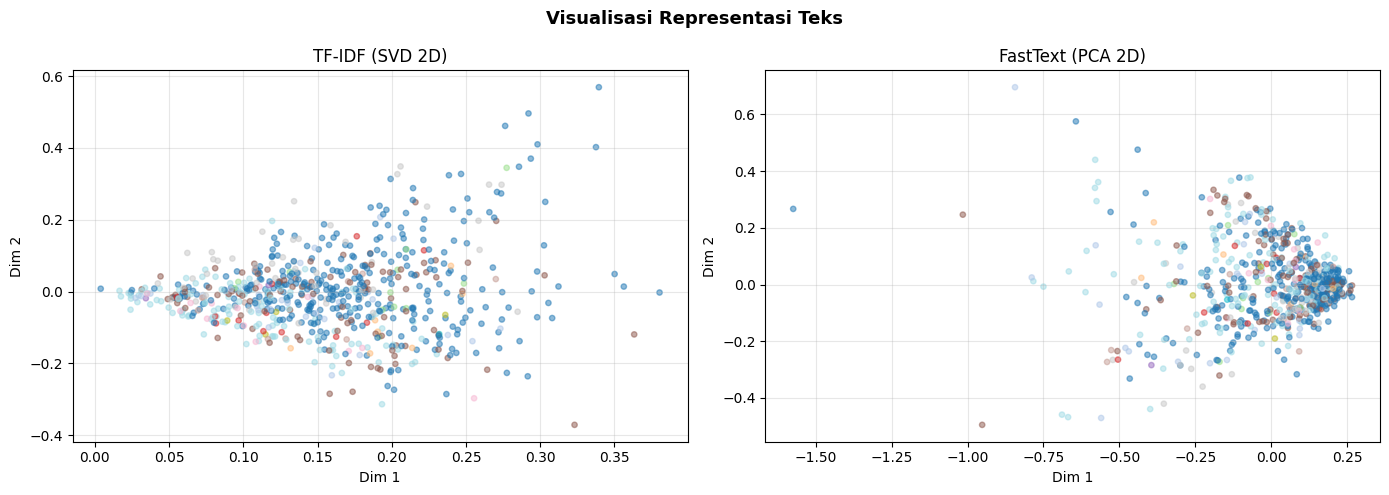

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

svd = TruncatedSVD(n_components=2, random_state=SEED)
tfidf_2d = svd.fit_transform(X_train_tfidf)

pca = PCA(n_components=2, random_state=SEED)
ft_2d = pca.fit_transform(X_train_ft)

first_label = np.argmax(Y_train, axis=1)
cmap = plt.cm.get_cmap('tab20', len(ALL_LABELS))

for ax, emb, title in zip(axes, [tfidf_2d, ft_2d], ['TF-IDF (SVD 2D)', 'FastText (PCA 2D)']):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=first_label,
                    cmap=cmap, alpha=0.5, s=15)
    ax.set_title(title); ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.grid(alpha=0.3)

plt.suptitle('Visualisasi Representasi Teks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('representation_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## A.5 Model Training dan Eksperimen

Dua pendekatan **problem transformation**:
- **Binary Relevance** — tiap label dilatih secara independen
- **Classifier Chain** — tiap label memperhitungkan prediksi label sebelumnya

Dua **algoritma klasifikasi** per pendekatan:
- Logistic Regression
- SVM (LinearSVC)

Masing-masing dicoba dengan **TF-IDF** dan **FastText** → total 8 kombinasi eksperimen.  
Tuning dilakukan via `C` parameter pada LR dan SVM.


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.multioutput import ClassifierChain as SKChain
from sklearn.multiclass import OneVsRestClassifier
from sklearn.base import clone
from packaging import version as pkg_version
import sklearn
import time

BASE_MODELS = {
    'LR_C1':  LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, class_weight='balanced'),
    'LR_C5':  LogisticRegression(C=5.0, max_iter=1000, random_state=SEED, class_weight='balanced'),
    'SVM_C1': LinearSVC(C=1.0, max_iter=2000, random_state=SEED, class_weight='balanced'),
    'SVM_C5': LinearSVC(C=5.0, max_iter=2000, random_state=SEED, class_weight='balanced'),
}

REPRS = {
    'TF-IDF':  (X_train_tfidf, X_val_tfidf,  X_test_tfidf),
    'FastText': (X_train_ft,   X_val_ft,      X_test_ft),
}

def make_model(transform: str, base):
    base_clone = clone(base)
    if transform == 'BinaryRelevance':
        return OneVsRestClassifier(estimator=base_clone, n_jobs=-1)
    else:
        try:
            return SKChain(estimator=base_clone, random_state=SEED)
        except TypeError:
            return SKChain(base_estimator=base_clone, random_state=SEED)

def evaluate_model(model, X_tr, Y_tr, X_v, Y_v):
    model.fit(X_tr, Y_tr)
    pred = model.predict(X_v)
    if hasattr(pred, 'toarray'):
        pred = pred.toarray()
    micro_f1 = f1_score(Y_v, pred, average='micro', zero_division=0)
    macro_f1 = f1_score(Y_v, pred, average='macro', zero_division=0)
    hl       = hamming_loss(Y_v, pred)
    subset   = accuracy_score(Y_v, pred)
    return micro_f1, macro_f1, hl, subset, pred

results = []
trained_models = {}

for repr_name, (Xtr, Xv, Xte) in REPRS.items():
    for base_name, base in BASE_MODELS.items():
        for transform in ['BinaryRelevance', 'ClassifierChain']:
            exp_name = f'{transform}|{base_name}|{repr_name}'
            t0 = time.time()
            model = make_model(transform, base)
            micro, macro, hl, subset, pred_val = evaluate_model(model, Xtr, Y_train, Xv, Y_val)
            elapsed = time.time() - t0
            results.append({
                'Experiment': exp_name, 'Transform': transform,
                'Model': base_name, 'Repr': repr_name,
                'Val micro-F1': round(micro, 4),
                'Val macro-F1': round(macro, 4),
                'Hamming Loss': round(hl, 4),
                'Subset Acc':   round(subset, 4),
                'Time(s)': round(elapsed, 1)
            })
            trained_models[exp_name] = (model, Xte)
            print(f'{exp_name:55s}  micro-F1={micro:.4f}  HL={hl:.4f}  [{elapsed:.1f}s]')

df_results = pd.DataFrame(results).sort_values('Val micro-F1', ascending=False)
print('\n=== Rangkuman Eksperimen ===')
display(df_results.reset_index(drop=True))

BinaryRelevance|LR_C1|TF-IDF                             micro-F1=0.6751  HL=0.0784  [2.3s]
ClassifierChain|LR_C1|TF-IDF                             micro-F1=0.6303  HL=0.0926  [0.2s]
BinaryRelevance|LR_C5|TF-IDF                             micro-F1=0.6724  HL=0.0769  [0.1s]
ClassifierChain|LR_C5|TF-IDF                             micro-F1=0.6653  HL=0.0815  [0.3s]
BinaryRelevance|SVM_C1|TF-IDF                            micro-F1=0.6565  HL=0.0795  [0.1s]
ClassifierChain|SVM_C1|TF-IDF                            micro-F1=0.6835  HL=0.0759  [0.1s]
BinaryRelevance|SVM_C5|TF-IDF                            micro-F1=0.6351  HL=0.0820  [0.1s]
ClassifierChain|SVM_C5|TF-IDF                            micro-F1=0.6435  HL=0.0830  [0.1s]
BinaryRelevance|LR_C1|FastText                           micro-F1=0.4657  HL=0.1893  [0.1s]
ClassifierChain|LR_C1|FastText                           micro-F1=0.3194  HL=0.2308  [0.2s]
BinaryRelevance|LR_C5|FastText                           micro-F1=0.5203  HL=0.1

,Experiment,Transform,Model,Repr,Val micro-F1,Val macro-F1,Hamming Loss,Subset Acc,Time(s)
0,ClassifierChain|SVM_C1|TF-IDF,ClassifierChain,SVM_C1,TF-IDF,0.6835,0.4322,0.0759,0.4539,0.1
1,BinaryRelevance|LR_C1|TF-IDF,BinaryRelevance,LR_C1,TF-IDF,0.6751,0.4290,0.0784,0.3816,2.3
2,BinaryRelevance|LR_C5|TF-IDF,BinaryRelevance,LR_C5,TF-IDF,0.6724,0.4191,0.0769,0.3750,0.1
3,ClassifierChain|LR_C5|TF-IDF,ClassifierChain,LR_C5,TF-IDF,0.6653,0.4144,0.0815,0.4276,0.3
4,BinaryRelevance|SVM_C1|TF-IDF,BinaryRelevance,SVM_C1,TF-IDF,0.6565,0.3834,0.0795,0.3882,0.1
5,ClassifierChain|SVM_C5|TF-IDF,ClassifierChain,SVM_C5,TF-IDF,0.6435,0.3586,0.0830,0.4408,0.1
6,BinaryRelevance|SVM_C5|TF-IDF,BinaryRelevance,SVM_C5,TF-IDF,0.6351,0.3665,0.0820,0.3553,0.1
7,ClassifierChain|LR_C1|TF-IDF,ClassifierChain,LR_C1,TF-IDF,0.6303,0.3710,0.0926,0.3750,0.2
8,BinaryRelevance|SVM_C5|FastText,BinaryRelevance,SVM_C5,FastText,0.5773,0.3780,0.1245,0.2303,0.4
9,ClassifierChain|SVM_C5|FastText,ClassifierChain,SVM_C5,FastText,0.5543,0.3034,0.1245,0.2697,0.6


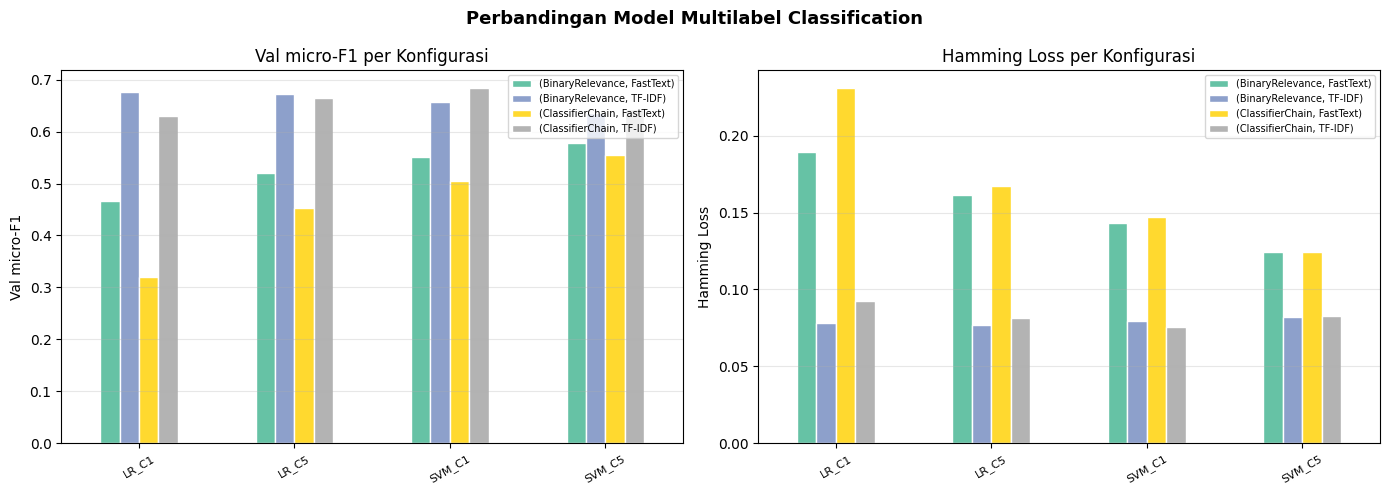

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['Val micro-F1', 'Hamming Loss']):
    pivot = df_results.pivot_table(index='Model', columns=['Transform','Repr'],
                                   values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'{metric} per Konfigurasi')
    ax.set_ylabel(metric); ax.set_xlabel('')
    ax.legend(fontsize=7, loc='best')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Model Multilabel Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## A.6 Evaluasi Model Terbaik dan Error Analysis

Model dengan **Val micro-F1 tertinggi** dipilih sebagai model terbaik.  
Evaluasi dilakukan pada **test set** dengan metrik lengkap.


In [ ]:
best_exp = df_results.iloc[0]['Experiment']
best_model, X_test_best = trained_models[best_exp]
print(f'Model terbaik (val): {best_exp}')
print(f'Val micro-F1       : {df_results.iloc[0]["Val micro-F1"]}')

Y_pred_test = best_model.predict(X_test_best)
if hasattr(Y_pred_test, 'toarray'):
    Y_pred_test = Y_pred_test.toarray()

micro = f1_score(Y_test, Y_pred_test, average='micro', zero_division=0)
macro = f1_score(Y_test, Y_pred_test, average='macro', zero_division=0)
weighted = f1_score(Y_test, Y_pred_test, average='weighted', zero_division=0)
hl   = hamming_loss(Y_test, Y_pred_test)
sub  = accuracy_score(Y_test, Y_pred_test)

print('\n=== Test Set Metrics ===')
print(f'Micro-F1    : {micro:.4f}')
print(f'Macro-F1    : {macro:.4f}')
print(f'Weighted-F1 : {weighted:.4f}')
print(f'Hamming Loss: {hl:.4f}')
print(f'Subset Acc  : {sub:.4f}')

print('\n=== Classification Report per Label ===')
print(classification_report(Y_test, Y_pred_test,
                             target_names=ALL_LABELS,
                             zero_division=0))


Model terbaik (val): ClassifierChain|SVM_C1|TF-IDF
Val micro-F1       : 0.6835

=== Test Set Metrics ===
Micro-F1    : 0.6320
Macro-F1    : 0.3377
Weighted-F1 : 0.6176
Hamming Loss: 0.0878
Subset Acc  : 0.3677

=== Classification Report per Label ===
                    precision    recall  f1-score   support

  PRODUCT_POSITIVE       0.74      0.77      0.76        71
  PRODUCT_NEGATIVE       0.11      0.14      0.12         7
   PRODUCT_NEUTRAL       0.00      0.00      0.00         3
    PRICE_POSITIVE       0.75      0.60      0.67        15
    PRICE_NEGATIVE       0.40      0.33      0.36         6
     PRICE_NEUTRAL       0.00      0.00      0.00         3
    PLACE_POSITIVE       0.70      0.74      0.72        43
    PLACE_NEGATIVE       0.00      0.00      0.00         6
     PLACE_NEUTRAL       0.67      0.33      0.44         6
PROMOTION_POSITIVE       0.74      0.65      0.69        26
PROMOTION_NEGATIVE       0.00      0.00      0.00         4
 PROMOTION_NEUTRAL       0.0

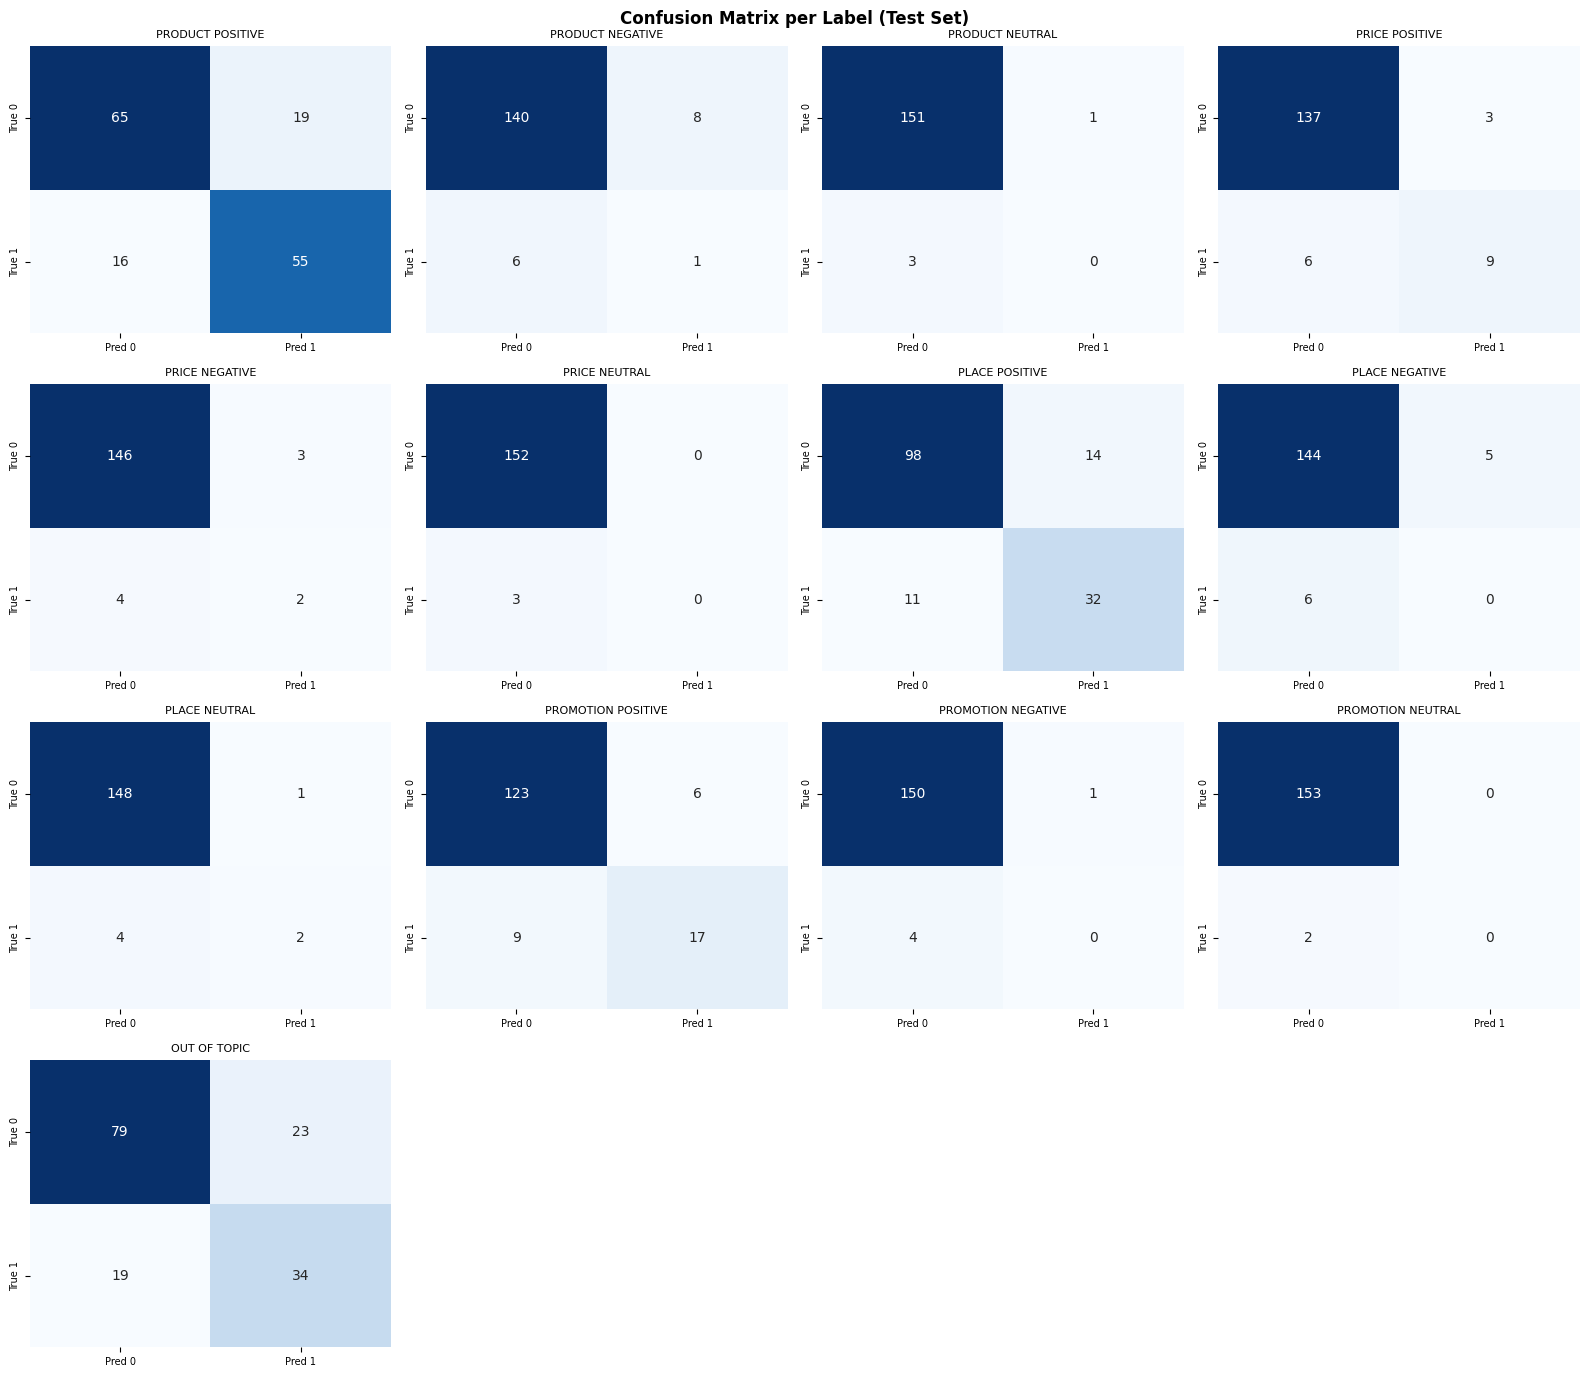

In [ ]:
n_labels = len(ALL_LABELS)
ncols = 4
nrows = (n_labels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, lbl in enumerate(ALL_LABELS):
    cm = confusion_matrix(Y_test[:, i], Y_pred_test[:, i])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                cbar=False)
    axes[i].set_title(lbl.replace('_',' '), fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrix per Label (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_multilabel.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
test_texts_raw = df_multi.iloc[idx_test]['text'].values

error_rows = []
for i, (true, pred) in enumerate(zip(Y_test, Y_pred_test)):
    true_labels = [ALL_LABELS[j] for j in range(len(ALL_LABELS)) if true[j]]
    pred_labels = [ALL_LABELS[j] for j in range(len(ALL_LABELS)) if pred[j]]
    if true_labels != pred_labels:
        fp = [l for l in pred_labels if l not in true_labels]  
        fn = [l for l in true_labels if l not in pred_labels]  
        error_rows.append({
            'text': test_texts_raw[i][:100] + '...' if len(test_texts_raw[i]) > 100 else test_texts_raw[i],
            'true_labels': true_labels,
            'pred_labels': pred_labels,
            'false_positive': fp,
            'false_negative': fn
        })

df_errors = pd.DataFrame(error_rows)
print(f'Total error: {len(df_errors)} / {len(Y_test)} ({len(df_errors)/len(Y_test)*100:.1f}%)')
print()
print('=== 10 Contoh Kesalahan Prediksi ===')
display(df_errors.head(10))

print()
fp_counts = Counter(l for row in error_rows for l in row['false_positive'])
fn_counts = Counter(l for row in error_rows for l in row['false_negative'])
print('False Positive terbanyak:', fp_counts.most_common(5))
print('False Negative terbanyak:', fn_counts.most_common(5))


Total error: 98 / 155 (63.2%)

=== 10 Contoh Kesalahan Prediksi ===


,text,true_labels,pred_labels,false_positive,false_negative
0,Tempat yang cocok untuk cari yang casual dan s...,[PLACE_POSITIVE],[PRODUCT_POSITIVE],[PRODUCT_POSITIVE],[PLACE_POSITIVE]
1,Sama seperti uniqlo lain di jogja,[PLACE_NEUTRAL],"[PRODUCT_NEGATIVE, PLACE_NEUTRAL]",[PRODUCT_NEGATIVE],[]
2,Barang ckup lengkap tapi diskon masih minim. S...,"[PRODUCT_POSITIVE, PRICE_POSITIVE]","[PRODUCT_NEGATIVE, PROMOTION_POSITIVE, PROMOTI...","[PRODUCT_NEGATIVE, PROMOTION_POSITIVE, PROMOTI...","[PRODUCT_POSITIVE, PRICE_POSITIVE]"
3,Nyari baju ke sini aja. Bagus dan nyaman.,"[PRODUCT_POSITIVE, PLACE_POSITIVE]",[PLACE_POSITIVE],[],[PRODUCT_POSITIVE]
4,Harusnya ada tempat penitipan makanan & minuma...,[PLACE_NEGATIVE],[OUT_OF_TOPIC],[OUT_OF_TOPIC],[PLACE_NEGATIVE]
5,"Permasalahan selalu sama, tidak melayani pemba...",[OUT_OF_TOPIC],"[PRODUCT_POSITIVE, PLACE_NEGATIVE]","[PRODUCT_POSITIVE, PLACE_NEGATIVE]",[OUT_OF_TOPIC]
6,Sangat luas berbagsi macam pakaian kekinian (s...,[PRODUCT_POSITIVE],"[PRODUCT_POSITIVE, OUT_OF_TOPIC]",[OUT_OF_TOPIC],[]
7,Sekuriti cukup membantu nyari anak ilang,[OUT_OF_TOPIC],"[PRODUCT_POSITIVE, OUT_OF_TOPIC]",[PRODUCT_POSITIVE],[]
8,Sama seperti uniqlo tempat lain. Keunggulan di...,"[PRODUCT_POSITIVE, PLACE_POSITIVE, PLACE_NEGAT...","[PRODUCT_POSITIVE, PLACE_POSITIVE]",[],"[PLACE_NEGATIVE, OUT_OF_TOPIC]"
9,"Toko fashion kekinian, merk terdengar jepang a...","[PRODUCT_POSITIVE, PRICE_POSITIVE, OUT_OF_TOPIC]","[PRODUCT_POSITIVE, PRICE_NEGATIVE]",[PRICE_NEGATIVE],"[PRICE_POSITIVE, OUT_OF_TOPIC]"



False Positive terbanyak: [('OUT_OF_TOPIC', 23), ('PRODUCT_POSITIVE', 19), ('PLACE_POSITIVE', 14), ('PRODUCT_NEGATIVE', 8), ('PROMOTION_POSITIVE', 6)]
False Negative terbanyak: [('OUT_OF_TOPIC', 19), ('PRODUCT_POSITIVE', 16), ('PLACE_POSITIVE', 11), ('PROMOTION_POSITIVE', 9), ('PRICE_POSITIVE', 6)]


In [ ]:
import joblib

MODEL_PATH = 'best_multilabel_model.joblib'
joblib.dump({'model': best_model, 'tfidf': tfidf, 'ft_model': ft_model,
             'mlb': mlb, 'best_exp': best_exp, 'repr_used': df_results.iloc[0]['Repr']},
            MODEL_PATH)
print(f'Model disimpan: {MODEL_PATH}')


Model disimpan: best_multilabel_model.joblib



# PROYEK B — Named Entity Recognition (NER) ABSA


## B.1 Data Loading dan Validasi Span

Dataset anotasi yang sama digunakan, namun kali ini fokus pada field `tokens` dan `spans`.  
Setiap record dikonversi menjadi pasangan `(token_list, tag_list)` dalam skema **BIO**.

Skema BIO yang digunakan:
- `B-<LABEL>` → token pertama dari span entitas
- `I-<LABEL>` → token lanjutan dalam span entitas
- `O` → token di luar entitas

Label entitas: PRODUCT_POSITIVE, PRODUCT_NEGATIVE, PRODUCT_NEUTRAL, PRICE_*, PLACE_*, PROMOTION_*, OUT_OF_TOPIC


In [ ]:
def record_to_bio(record: dict, scheme: str = "aspect_only") -> Tuple[List[str], List[str]]:
    """
    Konversi satu record Prodigy ke pasangan (tokens, bio_tags).
    token_end bersifat INCLUSIVE (dikonfirmasi dari eksplorasi data).

    scheme:
      - "aspect_only" -> label NER hanya aspek (PRODUCT/PRICE/PLACE/PROMOTION/OUT_OF_TOPIC),
                         sentimen tetap diambil dari model multilabel (Proyek A).
      - "aspect_sentiment" -> skema lama (aspek+sentimen digabung), untuk pembanding.
    """
    tokens = [t['text'] for t in record['tokens']]
    tags = ['O'] * len(tokens)
    for span in record.get('spans', []):
        ts, te = span['token_start'], span['token_end']
        label  = span['label']
        if scheme == "aspect_only":
            label = label.split('_')[0]  
        if ts < len(tags):
            tags[ts] = f'B-{label}'
            for i in range(ts + 1, min(te + 1, len(tags))):
                tags[i] = f'I-{label}'
    return tokens, tags

NER_SCHEME = "aspect_only"   

ner_records = []
for r in ann_records:
    tokens, tags = record_to_bio(r, scheme=NER_SCHEME)
    ner_records.append({'tokens': tokens, 'tags': tags, 'text': r['text']})

print(f'Skema tag yang dipakai : {NER_SCHEME}')
print(f'Total NER records      : {len(ner_records)}')

errors = 0
for r in ann_records:
    for span in r.get('spans', []):
        ts, te = span['token_start'], span['token_end']
        if te >= len(r['tokens']):
            errors += 1
print(f'Offset error (token_end OOB): {errors}')

print('\n=== Contoh Record NER ===')
sample = ner_records[1]
df_sample = pd.DataFrame({'token': sample['tokens'], 'tag': sample['tags']})
print('Text:', sample['text'][:100])
display(df_sample.T)

Skema tag yang dipakai : aspect_only
Total NER records      : 1013
Offset error (token_end OOB): 0

=== Contoh Record NER ===
Text: Tempat yang cocok untuk cari yang casual dan simple


,0,1,2,3,4,5,6,7,8
token,Tempat,yang,cocok,untuk,cari,yang,casual,dan,simple
tag,O,O,O,O,O,O,O,O,O


In [ ]:
all_tags_flat = [tag for r in ner_records for tag in r['tags']]
tag_dist = Counter(all_tags_flat)
print('Distribusi BIO tag:')
for tag, cnt in sorted(tag_dist.items(), key=lambda x: -x[1]):
    print(f'  {tag:<30} {cnt}')
print(f'\nTotal token : {len(all_tags_flat)}')
print(f'Total "O"   : {tag_dist["O"]} ({tag_dist["O"]/len(all_tags_flat)*100:.1f}%)')

NER_LABELS_RAW = sorted(set(t.split('-', 1)[1] for t in all_tags_flat if t != 'O'))
BIO_LABELS = ['O'] + [f'B-{l}' for l in NER_LABELS_RAW] + [f'I-{l}' for l in NER_LABELS_RAW]
print(f'\nJumlah entitas unik: {len(NER_LABELS_RAW)}')
print(f'Total BIO tag unik : {len(BIO_LABELS)}')


Distribusi BIO tag:
  O                              4188
  I-OUT                          3222
  I-PRODUCT                      2868
  I-PLACE                        1539
  I-PROMOTION                    1016
  I-PRICE                        618
  B-PRODUCT                      605
  B-PLACE                        427
  B-OUT                          399
  B-PROMOTION                    221
  B-PRICE                        161

Total token : 15264
Total "O"   : 4188 (27.4%)

Jumlah entitas unik: 5
Total BIO tag unik : 11


## B.2 Tokenisasi dan Konversi Tag (Alignment IndoBERT)

IndoBERT menggunakan **subword tokenizer** (WordPiece).  
Strategi alignment:
- Token asli → bisa pecah menjadi beberapa subword
- Label BIO ditempatkan di **subword pertama** saja
- Subword lanjutan diberi label `-100` (diabaikan oleh PyTorch loss)

Split data: **70 / 15 / 15** (train/val/test), stratifikasi berdasarkan label dominan.


In [ ]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if not getattr(tokenizer, 'is_fast', False):
    raise ValueError('Butuh fast tokenizer agar word_ids() tersedia.')

print(f'Tokenizer: {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size}')


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer: indobenchmark/indobert-base-p1
Vocab size: 30521


In [ ]:
tag2id = {tag: i for i, tag in enumerate(BIO_LABELS)}
id2tag = {i: tag for tag, i in tag2id.items()}
PAD_TAG_ID = -100

print('Tag → ID mapping (sample):')
for t, i in list(tag2id.items())[:6]:
    print(f'  {t:<25} → {i}')
print(f'  ... total {len(tag2id)} tag')


Tag → ID mapping (sample):
  O                         → 0
  B-OUT                     → 1
  B-PLACE                   → 2
  B-PRICE                   → 3
  B-PRODUCT                 → 4
  B-PROMOTION               → 5
  ... total 11 tag


In [ ]:
def dominant_label(tags: List[str]) -> str:
    """Label non-O yang paling sering muncul di satu record, untuk dasar stratifikasi."""
    counts = Counter(t.split('-', 1)[1] for t in tags if t != 'O')
    return counts.most_common(1)[0][0] if counts else 'NONE'

dom_labels = [dominant_label(r['tags']) for r in ner_records]

idx_all = list(range(len(ner_records)))
idx_trainval, idx_test = train_test_split(
    idx_all, test_size=0.15, random_state=SEED, stratify=dom_labels)

dom_trainval = [dom_labels[i] for i in idx_trainval]
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.176, random_state=SEED, stratify=dom_trainval) 

ner_train = [ner_records[i] for i in idx_train]
ner_val   = [ner_records[i] for i in idx_val]
ner_test  = [ner_records[i] for i in idx_test]

print(f'NER Train : {len(ner_train)}')
print(f'NER Val   : {len(ner_val)}')
print(f'NER Test  : {len(ner_test)}')

for split_name, split_data in [('train', ner_train), ('val', ner_val), ('test', ner_test)]:
    with open(f'Kelp1_ner_{split_name}.jsonl', 'w', encoding='utf-8') as f:
        for r in split_data:
            f.write(json.dumps(r, ensure_ascii=False) + '\n')
print('NER split files disimpan ✓ (stratified by dominant label)')

NER Train : 709
NER Val   : 152
NER Test  : 152
NER split files disimpan ✓ (stratified by dominant label)


## B.3 EDA dan Visualisasi Entitas NER


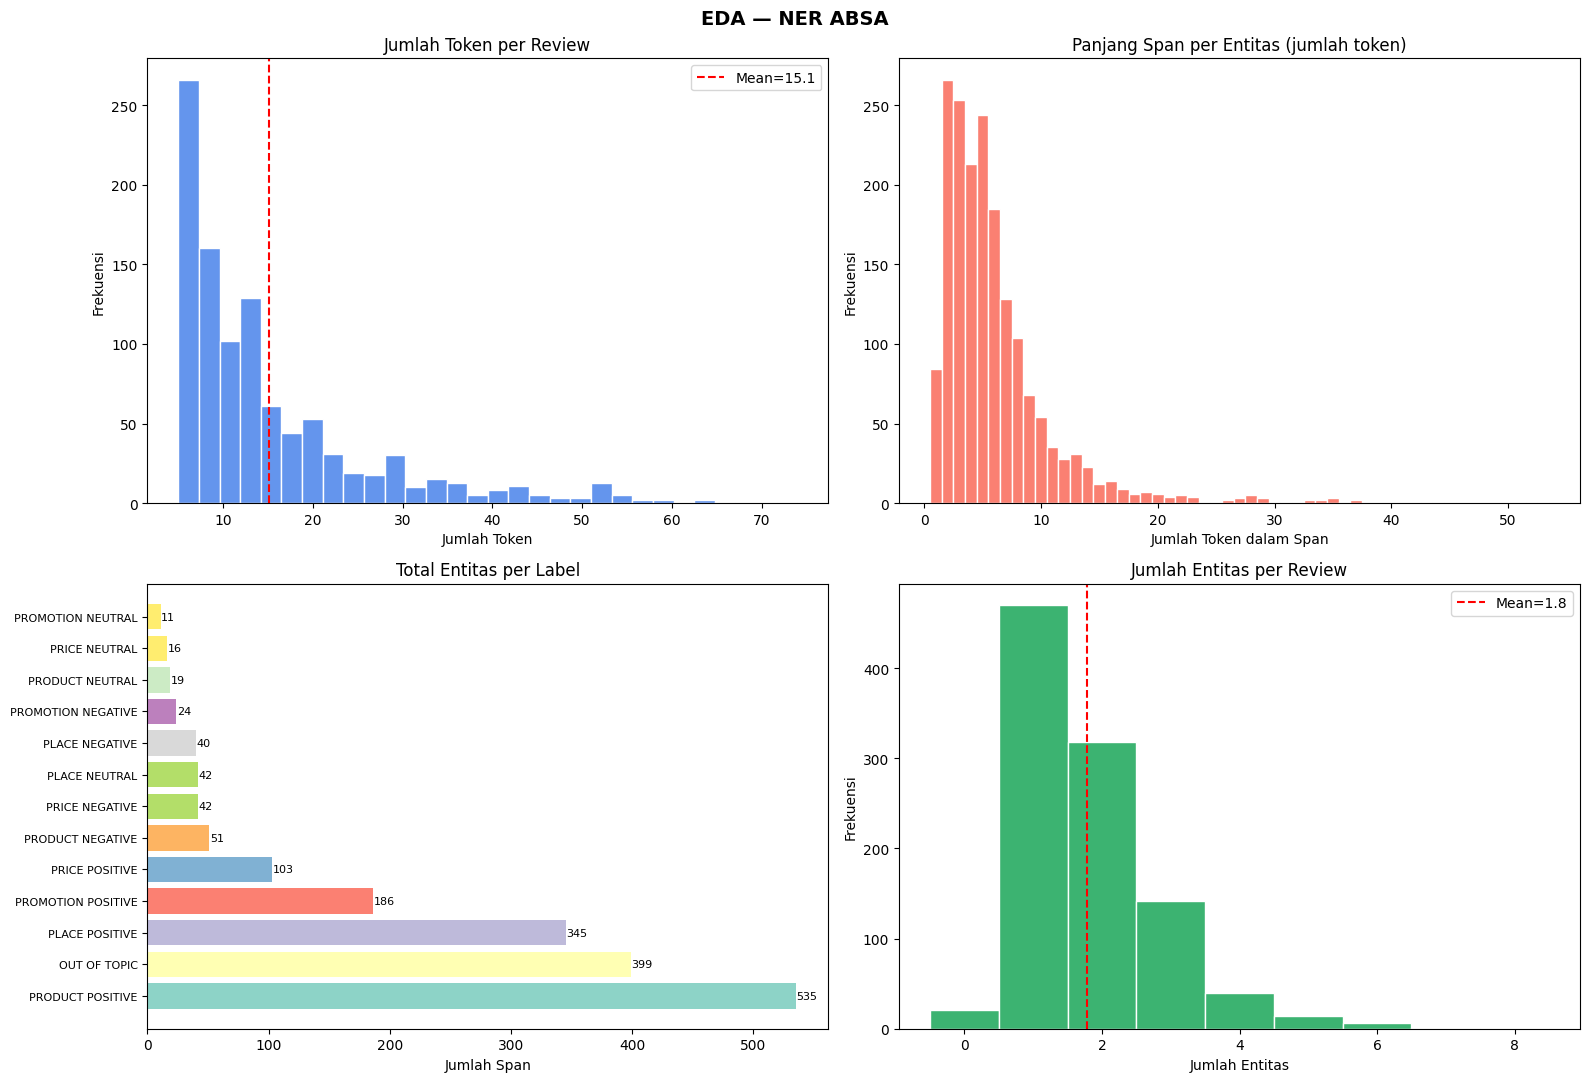

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('EDA — NER ABSA', fontsize=14, fontweight='bold')

ax = axes[0, 0]
tok_counts = [len(r['tokens']) for r in ner_records]
ax.hist(tok_counts, bins=30, color='cornflowerblue', edgecolor='white')
ax.set_title('Jumlah Token per Review')
ax.set_xlabel('Jumlah Token'); ax.set_ylabel('Frekuensi')
ax.axvline(np.mean(tok_counts), color='red', linestyle='--',
           label=f'Mean={np.mean(tok_counts):.1f}')
ax.legend()

ax = axes[0, 1]
span_lens = []
span_lbls = []
for r in ann_records:
    for span in r.get('spans', []):
        span_lens.append(span['token_end'] - span['token_start'] + 1)
        span_lbls.append(span['label'])
ax.hist(span_lens, bins=range(1, max(span_lens)+2), color='salmon', edgecolor='white', align='left')
ax.set_title('Panjang Span per Entitas (jumlah token)')
ax.set_xlabel('Jumlah Token dalam Span'); ax.set_ylabel('Frekuensi')

ax = axes[1, 0]
span_label_dist = Counter(span_lbls)
labels_sorted = sorted(span_label_dist.keys(), key=lambda x: -span_label_dist[x])
counts_sorted = [span_label_dist[l] for l in labels_sorted]
colors = plt.cm.Set3(np.linspace(0, 1, len(labels_sorted)))
bars = ax.barh(range(len(labels_sorted)), counts_sorted, color=colors)
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels([l.replace('_',' ') for l in labels_sorted], fontsize=8)
ax.set_title('Total Entitas per Label')
ax.set_xlabel('Jumlah Span')
for bar, count in zip(bars, counts_sorted):
    ax.text(count + 0.5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=8)

ax = axes[1, 1]
entities_per_review = [len(r.get('spans', [])) for r in ann_records]
ax.hist(entities_per_review, bins=range(0, max(entities_per_review)+2),
        color='mediumseagreen', edgecolor='white', align='left')
ax.set_title('Jumlah Entitas per Review')
ax.set_xlabel('Jumlah Entitas'); ax.set_ylabel('Frekuensi')
ax.axvline(np.mean(entities_per_review), color='red', linestyle='--',
           label=f'Mean={np.mean(entities_per_review):.1f}')
ax.legend()

plt.tight_layout()
plt.savefig('eda_ner.png', dpi=150, bbox_inches='tight')
plt.show()


## B.4 Feature Engineering — Embedding dan Alignment Label

**IndoBERT** digunakan sebagai encoder subword.  
Setiap record diubah menjadi:
- `input_ids`, `attention_mask`, `token_type_ids` → dari tokenizer
- `labels` → BIO tag per subword (subword lanjutan = `-100`)

Strategi imbalance: label `O` mendominasi (~27% token), namun karena CRF secara eksplisit memodelkan transisi antartag, distribusi ini ditangani oleh struktur model — tidak perlu oversampling.


In [ ]:
MAX_LEN = 128

class ABSANERDataset(Dataset):
    def __init__(self, records, tokenizer, tag2id, max_len=MAX_LEN):
        self.records   = records
        self.tokenizer = tokenizer
        self.tag2id    = tag2id
        self.max_len   = max_len
        self.items     = []
        self._build()

    def _build(self):
        for rec in self.records:
            tokens = rec['tokens']
            tags   = rec['tags']

            enc = self.tokenizer(
                tokens,
                is_split_into_words=True,
                padding='max_length',
                truncation=True,
                max_length=self.max_len,
                return_tensors='pt',
                return_token_type_ids=True,  
            )

            input_ids      = enc['input_ids'].squeeze(0)        
            attention_mask = enc['attention_mask'].squeeze(0)   
            
            if 'token_type_ids' in enc and enc['token_type_ids'] is not None:
                token_type_ids = enc['token_type_ids'].squeeze(0)
            else:
                token_type_ids = torch.zeros(self.max_len, dtype=torch.long)

            assert input_ids.shape      == (self.max_len,), f'input_ids shape {input_ids.shape}'
            assert attention_mask.shape == (self.max_len,), f'attn_mask shape {attention_mask.shape}'
            assert token_type_ids.shape == (self.max_len,), f'tti shape {token_type_ids.shape}'

            word_ids = enc.word_ids(batch_index=0)
            label_ids    = []
            prev_word_id = None
            for i, wid in enumerate(word_ids):
                if wid is None:
                    if i == 0: 
                        label_ids.append(self.tag2id['O'])
                    else: 
                        label_ids.append(PAD_TAG_ID)
                elif wid != prev_word_id:
                    label_ids.append(self.tag2id.get(tags[wid], self.tag2id['O']))
                else:
                    label_ids.append(PAD_TAG_ID)
                prev_word_id = wid

            self.items.append({
                'input_ids':      input_ids,
                'attention_mask': attention_mask,
                'token_type_ids': token_type_ids,
                'labels':         torch.tensor(label_ids, dtype=torch.long),
                'tokens_raw':     tokens,
                'tags_raw':       tags,
            })

    def __len__(self): return len(self.items)
    def __getitem__(self, idx): return self.items[idx]

def ner_collate_fn(batch):
    """Custom collate function to handle varying-length raw token/tag lists."""
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    token_type_ids = torch.stack([item['token_type_ids'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    tokens_raw = [item['tokens_raw'] for item in batch]
    tags_raw = [item['tags_raw'] for item in batch]

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'token_type_ids': token_type_ids,
        'labels': labels,
        'tokens_raw': tokens_raw,
        'tags_raw': tags_raw,
    }

train_dataset = ABSANERDataset(ner_train, tokenizer, tag2id, MAX_LEN)
val_dataset   = ABSANERDataset(ner_val,   tokenizer, tag2id, MAX_LEN)
test_dataset  = ABSANERDataset(ner_test,  tokenizer, tag2id, MAX_LEN)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=ner_collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=ner_collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=ner_collate_fn)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

sample = train_dataset[0]
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        print(f'  {k}: {v.shape}')

Train batches: 45
Val   batches: 10
Test  batches: 10
  input_ids: torch.Size([128])
  attention_mask: torch.Size([128])
  token_type_ids: torch.Size([128])
  labels: torch.Size([128])


## B.5 Model — IndoBERT + CRF Token Classification

Arsitektur:
1. **IndoBERT encoder** (`indobenchmark/indobert-base-p1`) → contextual subword embeddings (768-dim)
2. **Linear projection** → emission scores untuk tiap BIO tag
3. **CRF layer** (via `torchcrf`) → sequence-level training loss + Viterbi decoding

CRF menghitung probability transisi antartag sehingga output prediksi lebih konsisten secara urutan tag (misalnya `I-X` tidak bisa muncul setelah `O` tanpa `B-X`).


In [ ]:
try:
    from torchcrf import CRF
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pytorch-crf'])
    from torchcrf import CRF

class IndoBERTCRF(nn.Module):
    """IndoBERT encoder + linear projection + CRF layer for token classification."""
    def __init__(self, model_name, num_tags, dropout=0.2, n_unfrozen_layers=6):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden_size     = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_tags)
        self.crf        = CRF(num_tags, batch_first=True) 

        for p in self.encoder.embeddings.parameters():
            p.requires_grad = False

        total_layers = len(self.encoder.encoder.layer)
        for i, layer in enumerate(self.encoder.encoder.layer):
            if i < total_layers - n_unfrozen_layers:
                for p in layer.parameters():
                    p.requires_grad = False

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask,
                                token_type_type_ids=token_type_ids)
        emissions = self.classifier(self.dropout(outputs.last_hidden_state))

        crf_mask = attention_mask.bool()

        if labels is not None:
            active_labels = labels.clone()
            active_labels[labels == PAD_TAG_ID] = 0 

            loss = -self.crf(emissions, active_labels, mask=crf_mask, reduction='mean')

            decoded_sequence = self.crf.decode(emissions, mask=crf_mask)
            return loss, decoded_sequence, emissions
        else:
            decoded_sequence = self.crf.decode(emissions, mask=crf_mask)
            return None, decoded_sequence, emissions 

NUM_TAGS = len(BIO_LABELS)
model_ner = IndoBERTCRF(MODEL_NAME, NUM_TAGS, dropout=0.2, n_unfrozen_layers=6).to(DEVICE)

total_params = sum(p.numel() for p in model_ner.parameters())
trainable    = sum(p.numel() for p in model_ner.parameters() if p.requires_grad)
print(f'Model NER: IndoBERTCRF (4 layer atas unfrozen)  |  num_tags={NUM_TAGS}  |  device={DEVICE}')
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable:,}  ({trainable/total_params*100:.1f}%)')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model NER: IndoBERTCRF (4 layer atas unfrozen)  |  num_tags=11  |  device=cuda
Total params    : 124,449,946
Trainable params: 43,126,426  (34.7%)


## B.6 Training dengan Early Stopping

- **Optimizer**: AdamW dengan weight decay
- **Scheduler**: Linear warmup kemudian linear decay
- **Early stopping**: berdasarkan **val entity-level F1** (seqeval)
- **Max epochs**: 10 (cukup untuk fine-tuning IndoBERT)

Model checkpoint disimpan setiap kali val F1 meningkat.


In [ ]:
LR           = 3e-5      
WEIGHT_DECAY = 0.02       
EPOCHS       = 25         
WARMUP_RATIO = 0.1
PATIENCE     = 5          

NUM_TRAINING_STEPS = len(train_loader) * EPOCHS
NUM_WARMUP_STEPS   = int(WARMUP_RATIO * NUM_TRAINING_STEPS)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_ner.parameters()),   
    lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=NUM_WARMUP_STEPS, num_training_steps=NUM_TRAINING_STEPS)

print(f'Training steps total  : {NUM_TRAINING_STEPS}')
print(f'Warmup steps          : {NUM_WARMUP_STEPS}')

Training steps total  : 1125
Warmup steps          : 112


In [ ]:
def decode_predictions(model, loader, device):
    """
    Decode prediksi NER dari DataLoader.
    Return: list of (true_tag_list, pred_tag_list) per sample,
    hanya pada posisi yang bukan PAD.
    """
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)

            _, decoded_sequence, _ = model(input_ids, attention_mask, token_type_ids)

            for i, seq_pred_indices in enumerate(decoded_sequence):
                label_row = labels[i].cpu().numpy()
                valid_positions = [j for j, l in enumerate(label_row) if l != PAD_TAG_ID]
                true_tags = [id2tag[label_row[j]] for j in valid_positions]
                pred_tags = [id2tag[idx] for idx in seq_pred_indices]

                current_true_tags = []
                for j, label_id in enumerate(label_row):
                    if label_id != PAD_TAG_ID:
                        current_true_tags.append(id2tag[label_id])
                original_seq_len = attention_mask[i].sum().item()

                true_tags_filtered = []
                for k in range(original_seq_len):
                    if label_row[k] != PAD_TAG_ID:
                        true_tags_filtered.append(id2tag[label_row[k]])

                if len(seq_pred_indices) != len(true_tags_filtered):
                    min_len = min(len(seq_pred_indices), len(true_tags_filtered))
                    all_true.append(true_tags_filtered[:min_len])
                    all_pred.append([id2tag[idx] for idx in seq_pred_indices[:min_len]])
                else:
                    all_true.append(true_tags_filtered)
                    all_pred.append([id2tag[idx] for idx in seq_pred_indices])

    return all_true, all_pred

In [ ]:
from tqdm.auto import tqdm

CHECKPOINT = 'best_ner_model.pt'
best_val_f1   = 0.0
patience_cnt  = 0
train_losses  = []
val_f1_scores = []

for epoch in range(1, EPOCHS + 1):
    model_ner.train()
    total_loss = 0.0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [Train]', leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        loss, _, _ = model_ner(input_ids, attention_mask, token_type_ids, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model_ner.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    true_val, pred_val = decode_predictions(model_ner, val_loader, DEVICE)
    val_f1 = seq_f1_score(true_val, pred_val, average='micro', zero_division=0)
    val_f1_scores.append(val_f1)

    print(f'Epoch {epoch:2d}  |  Train Loss: {avg_loss:.4f}  |  Val F1 (entity): {val_f1:.4f}', end='')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_cnt = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_ner.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'tag2id': tag2id, 'id2tag': id2tag,
        }, CHECKPOINT)
        print('  ← best ✓', end='')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarly stopping pada epoch {epoch} (patience={PATIENCE})')
            break
    print()

print(f'\nBest Val F1: {best_val_f1:.4f}')

Epoch 1/25 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Epoch  1  |  Train Loss: 2.1483  |  Val F1 (entity): 0.0395  ← best ✓


Epoch 2/25 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch  2  |  Train Loss: 1.4101  |  Val F1 (entity): 0.0988  ← best ✓


...

Epoch 13  |  Train Loss: 0.0740  |  Val F1 (entity): 0.1886


Epoch 14/25 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 14  |  Train Loss: 0.0595  |  Val F1 (entity): 0.1970


Epoch 15/25 [Train]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 15  |  Train Loss: 0.0472  |  Val F1 (entity): 0.1870
Early stopping pada epoch 15 (patience=5)

Best Val F1: 0.2017


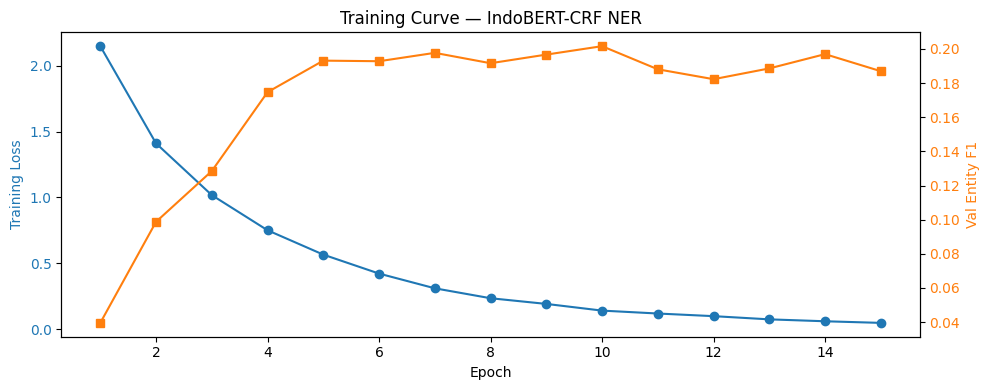

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 4))
color1, color2 = 'tab:blue', 'tab:orange'

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Training Loss', color=color1)
ax1.plot(range(1, len(train_losses)+1), train_losses, color=color1, marker='o', label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.set_ylabel('Val Entity F1', color=color2)
ax2.plot(range(1, len(val_f1_scores)+1), val_f1_scores, color=color2, marker='s', label='Val F1')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Training Curve — IndoBERT-CRF NER')
fig.tight_layout()
plt.savefig('training_curve_ner.png', dpi=120, bbox_inches='tight')
plt.show()


## B.7 Evaluasi Model dan Error Analysis

Load checkpoint terbaik, evaluasi pada **test set** dengan:
- Classification report token-level dan entity-level (seqeval)
- Confusion matrix token-level
- Contoh prediksi benar dan salah
- Analisis **boundary error** dan **label error**


In [ ]:
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model_ner.load_state_dict(ckpt['model_state_dict'])
model_ner.to(DEVICE)
print(f'Loaded checkpoint dari epoch {ckpt["epoch"]} (val F1={ckpt["val_f1"]:.4f})')

true_test, pred_test = decode_predictions(model_ner, test_loader, DEVICE)

print('\n=== Entity-Level Classification Report (seqeval) ===')
print(seq_classification_report(true_test, pred_test, digits=4, zero_division=0))
entity_f1 = seq_f1_score(true_test, pred_test, average='micro', zero_division=0)
print(f'Overall Entity micro-F1: {entity_f1:.4f}')

flat_true = [t for seq in true_test for t in seq]
flat_pred = [t for seq in pred_test for t in seq]
unique_token_labels = sorted(set(flat_true + flat_pred))
print('\n=== Token-Level Classification Report ===')
print(classification_report(flat_true, flat_pred,
                             labels=unique_token_labels,
                             zero_division=0, digits=4))

Loaded checkpoint dari epoch 10 (val F1=0.2017)

=== Entity-Level Classification Report (seqeval) ===
              precision    recall  f1-score   support

         OUT     0.0811    0.1579    0.1071        57
       PLACE     0.2532    0.2817    0.2667        71
       PRICE     0.0909    0.1429    0.1111        21
     PRODUCT     0.2014    0.3085    0.2437        94
   PROMOTION     0.2143    0.2647    0.2368        34

   micro avg     0.1711    0.2527    0.2041       277
   macro avg     0.1682    0.2311    0.1931       277
weighted avg     0.1831    0.2527    0.2106       277

Overall Entity micro-F1: 0.2041

=== Token-Level Classification Report ===
              precision    recall  f1-score   support

       B-OUT     0.5294    0.4737    0.5000        57
     B-PLACE     0.5965    0.4789    0.5312        71
     B-PRICE     0.3684    0.3333    0.3500        21
   B-PRODUCT     0.5056    0.4787    0.4918        94
 B-PROMOTION     0.5172    0.4412    0.4762        34
       I-

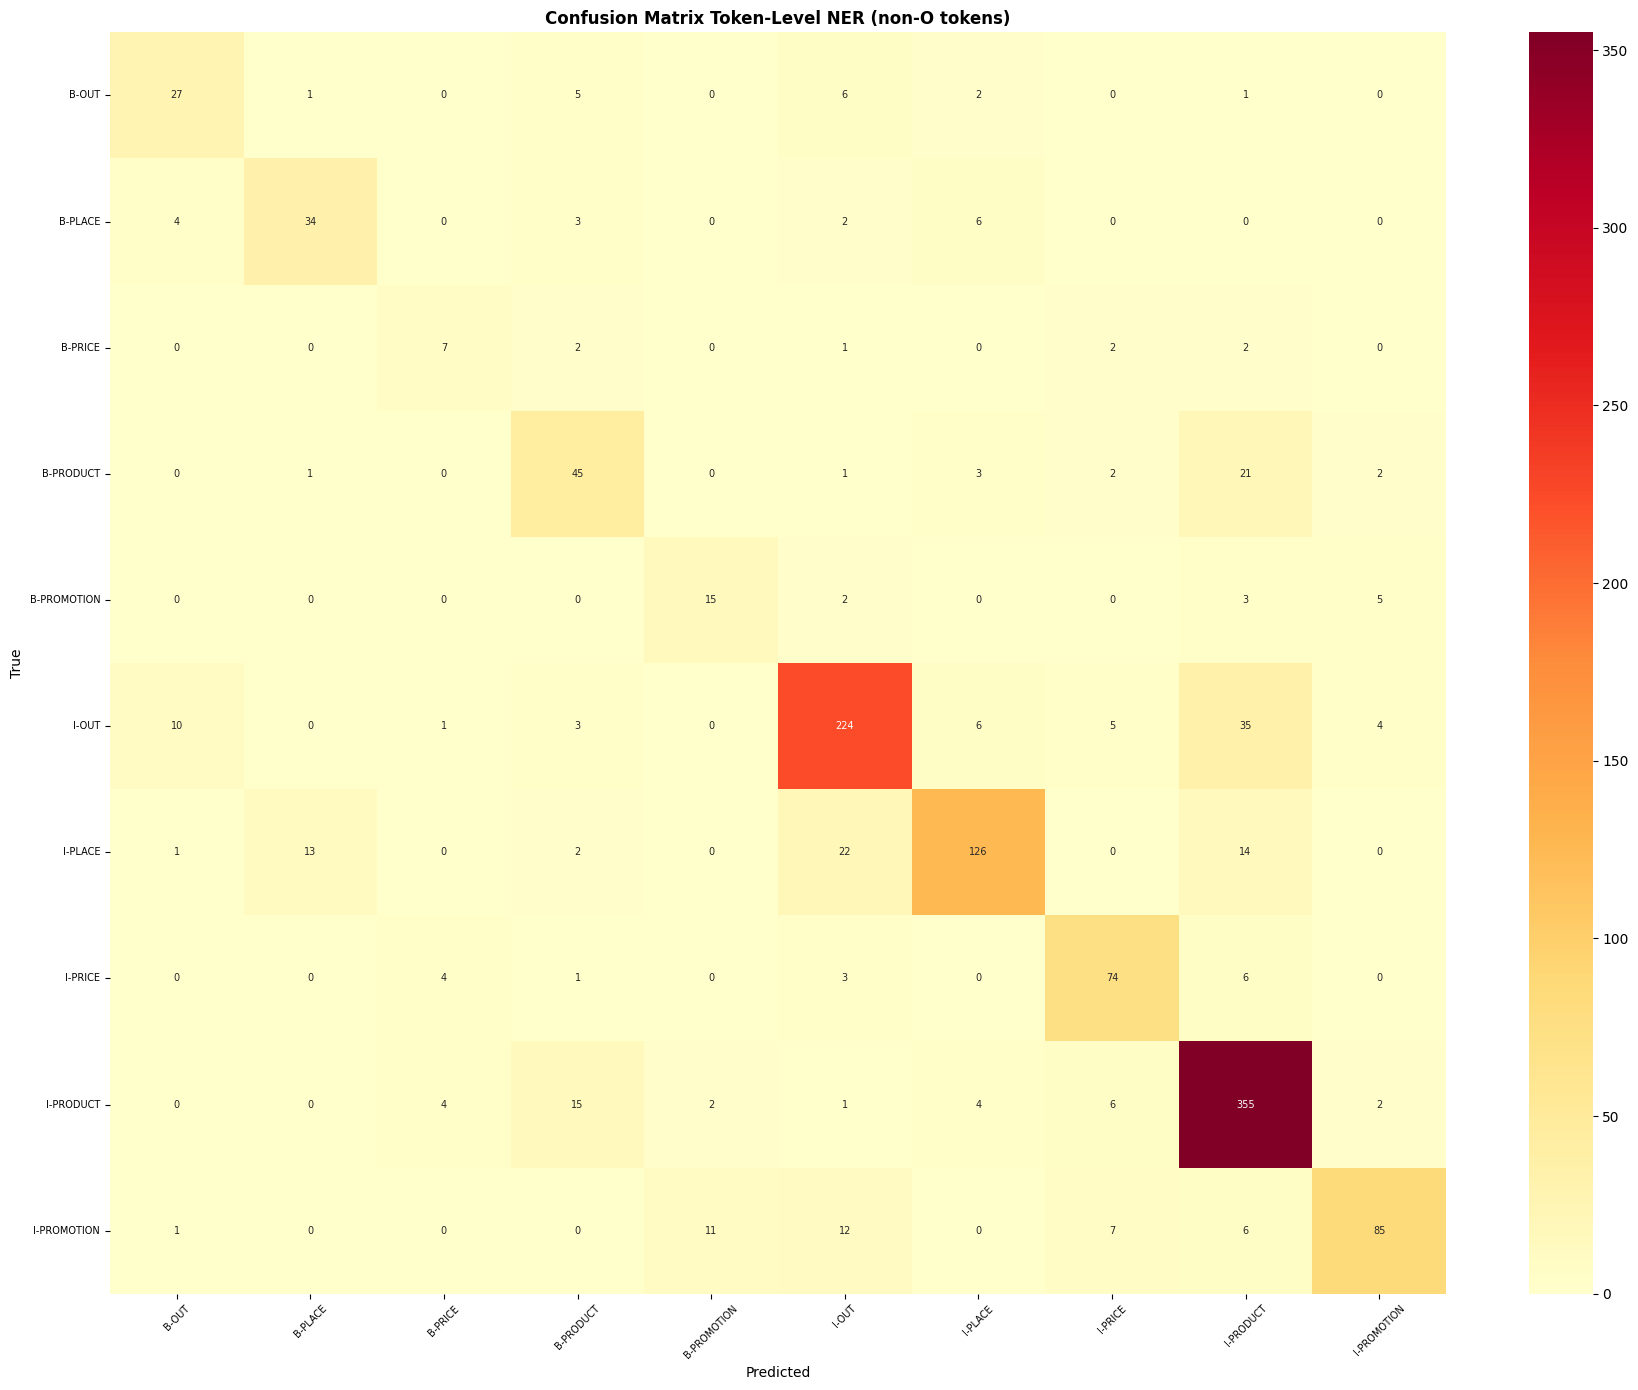

In [ ]:
non_o_labels = [l for l in unique_token_labels if l != 'O']
flat_true_filt = [t if t != 'O' else None for t in flat_true]
flat_pred_filt = [t if t != 'O' else None for t in flat_pred]

cm = confusion_matrix(
    [t for t in flat_true if t != 'O'],
    [flat_pred[i] for i, t in enumerate(flat_true) if t != 'O'],
    labels=non_o_labels
)

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[l.replace('_',' ')[:18] for l in non_o_labels],
            yticklabels=[l.replace('_',' ')[:18] for l in non_o_labels],
            ax=ax, annot_kws={'size': 7})
ax.set_title('Confusion Matrix Token-Level NER (non-O tokens)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix_ner.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
print('=== 5 Contoh Prediksi Benar ===')
correct_idx = [i for i, (t, p) in enumerate(zip(true_test, pred_test)) if t == p]
for idx in correct_idx[:5]:
    raw = ner_test[idx]['tokens']
    t_seq = true_test[idx]
    p_seq = pred_test[idx]

    common_len = len(t_seq)
    tokens_for_df = raw[:common_len]
    if len(tokens_for_df) < common_len:
        tokens_for_df.extend([''] * (common_len - len(tokens_for_df))) 

    print(f'  Text: {" ".join(raw[:20])}')
    df_show = pd.DataFrame({
        'token': tokens_for_df,
        'true': t_seq,
        'pred': p_seq
    })
    display(df_show[df_show['true'] != 'O'].head(8))
    print()

print('\n=== 5 Contoh Prediksi Salah ===')
wrong_idx = [i for i, (t, p) in enumerate(zip(true_test, pred_test)) if t != p]
for idx in wrong_idx[:5]:
    raw = ner_test[idx]['tokens']
    t_seq = true_test[idx]
    p_seq = pred_test[idx]

    common_len = len(t_seq)
    tokens_for_df = raw[:common_len]
    if len(tokens_for_df) < common_len:
        tokens_for_df.extend([''] * (common_len - len(tokens_for_df))) 

    print(f'  Text: {" ".join(raw[:20])}')
    df_show = pd.DataFrame({
        'token': tokens_for_df,
        'true': t_seq,
        'pred': p_seq
    })
    df_wrong = df_show[df_show['true'] != df_show['pred']]
    display(df_wrong.head(8))
    print()


=== 5 Contoh Prediksi Benar ===
  Text: Tempatnya luas dan nyaman buat belanja


,token,true,pred
1,luas,B-PLACE,B-PLACE
2,dan,I-PLACE,I-PLACE
3,nyaman,I-PLACE,I-PLACE
4,buat,I-PLACE,I-PLACE
5,belanja,I-PLACE,I-PLACE
6,,I-PLACE,I-PLACE



  Text: Cukup banyak pilihan merek dan jenis fashion


,token,true,pred
1,banyak,B-PRODUCT,B-PRODUCT
2,pilihan,I-PRODUCT,I-PRODUCT
3,merek,I-PRODUCT,I-PRODUCT
4,dan,I-PRODUCT,I-PRODUCT
5,jenis,I-PRODUCT,I-PRODUCT
6,fashion,I-PRODUCT,I-PRODUCT
7,,I-PRODUCT,I-PRODUCT



  Text: Fashion store yang cukup lengkap


...

,token,true,pred
4,Kainnya,O,I-PRODUCT
5,adem,B-PRODUCT,I-PRODUCT



  Text: Mayan akhir tahun banyaak diskon .. buruaaan


,token,true,pred
6,buruaaan,O,I-PROMOTION
7,,O,I-PROMOTION



  Text: Tempat bagus dan lebih besar dari mall lain yang terletak di daerah Jogja .


,token,true,pred
3,lebih,O,I-PLACE
4,besar,B-PLACE,I-PLACE
12,Jogja,I-PLACE,I-OUT
14,,I-PLACE,O


In [ ]:
boundary_errors = 0
label_errors    = 0
correct_spans   = 0
total_spans     = 0

for t_seq, p_seq in zip(true_test, pred_test):
    n = min(len(t_seq), len(p_seq))
    for t, p in zip(t_seq[:n], p_seq[:n]):
        if t == 'O' and p == 'O':
            continue
        if t != 'O':
            total_spans += 1
        if t == p:
            correct_spans += 1
        elif t != 'O' and p != 'O':
            t_ent = t.split('-', 1)[1] if '-' in t else t
            p_ent = p.split('-', 1)[1] if '-' in p else p
            if t_ent == p_ent:
                boundary_errors += 1   
            else:
                label_errors += 1      
        elif t != 'O' and p == 'O':
            boundary_errors += 1       
        elif t == 'O' and p != 'O':
            boundary_errors += 1       

print('=== Error Analysis ===')
print(f'Total non-O token (true)  : {total_spans}')
print(f'Correct                   : {correct_spans} ({correct_spans/max(1,total_spans)*100:.1f}%)')
print(f'Boundary errors           : {boundary_errors} ({boundary_errors/max(1,total_spans)*100:.1f}%)')
print(f'Label errors              : {label_errors} ({label_errors/max(1,total_spans)*100:.1f}%)')
print()
print('Boundary errors terjadi ketika model gagal menentukan awal/akhir span (B vs I)')
print('atau melewatkan/menambah entitas (FP/FN).')
print('Label errors terjadi ketika span terdeteksi tapi jenis/sentimen entitas salah.')


=== Error Analysis ===
Total non-O token (true)  : 1628
Correct                   : 992 (60.9%)
Boundary errors           : 801 (49.2%)
Label errors              : 185 (11.4%)

Boundary errors terjadi ketika model gagal menentukan awal/akhir span (B vs I)
atau melewatkan/menambah entitas (FP/FN).
Label errors terjadi ketika span terdeteksi tapi jenis/sentimen entitas salah.


## B.8 Simpan Model NER untuk Deployment

Simpan tokenizer, tag mapping, dan model state dict agar bisa dimuat ulang di Streamlit.


In [ ]:
NER_DIR = Path('ner_model_artifacts')
NER_DIR.mkdir(exist_ok=True)

model_ner.encoder.save_pretrained(NER_DIR / 'encoder')
tokenizer.save_pretrained(NER_DIR)

torch.save(
    {
        'classifier_state': model_ner.classifier.state_dict(),
        'crf_state':        model_ner.crf.state_dict(), 
        'tag2id': tag2id,
        'id2tag': id2tag,
        'num_tags': NUM_TAGS,
        'max_len': MAX_LEN,
        'model_name': MODEL_NAME,
    },
    NER_DIR / 'crf_head.pt',
)

print(f'Artefak NER disimpan di: {NER_DIR}')
print('  ├── encoder/  (HuggingFace)')
print('  ├── tokenizer files')
print('  └── crf_head.pt')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Artefak NER disimpan di: ner_model_artifacts
  ├── encoder/  (HuggingFace)
  ├── tokenizer files
  └── crf_head.pt


---
## Ringkasan Perbandingan Proyek A dan Proyek B

| Aspek | Proyek A (Multilabel) | Proyek B (NER) |
|---|---|---|
| **Level analisis** | Review-level | Token-level |
| **Output** | Label ABSA (13 kelas multi-hot) | Tag BIO per token |
| **Model** | BinaryRelevance / ClassifierChain + TF-IDF / FastText | IndoBERT + CRF |
| **Evaluasi** | micro/macro F1, Hamming Loss, Subset Acc | Entity F1 (seqeval), Token F1 |
| **Keterkaitan** | Label multilabel menyatakan *ada* sentimen X pada review | Span NER menunjukkan *di bagian mana* sentimen X muncul |

**Hubungan output**: label multilabel Proyek A dan span NER Proyek B saling melengkapi.  
Contoh: jika Proyek A memprediksi `PRODUCT_POSITIVE`, Proyek B akan menunjukkan span kalimat spesifik yang mengandung opini positif tersebut.  
Penyebab error NER yang paling umum adalah **boundary error** , model tahu jenis entitasnya tetapi kesulitan menentukan batas awal/akhir span, terutama pada kalimat panjang atau entitas yang ambigu.


In [ ]:
import zipfile
import os
from google.colab import files
from pathlib import Path

NER_DIR = Path('ner_model_artifacts')
output_filename = 'ner_model_artifacts.zip'

if not NER_DIR.exists():
    print(f"Directory '{NER_DIR}' not found. Please ensure cell opjl7QEsgNGX has been executed to save the model artifacts.")
else:
    with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files_in_dir in os.walk(NER_DIR):
            for file in files_in_dir:
                file_path = os.path.join(root, file)
                arcname = Path(file_path).relative_to(NER_DIR)
                zipf.write(file_path, arcname)

    files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>